In [9]:
import pandas as pd

df_dataset = pd.read_csv("ai_student_impact_dataset.csv")

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [10]:
X_train = df_dataset.copy()

In [11]:
mappa_skills = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
X_train['Prompt_Engineering_Skill_Num'] = X_train['Prompt_Engineering_Skill'].map(mappa_skills)



In [17]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    50000 non-null  int64  
 1   Major_Category                50000 non-null  str    
 2   Year_of_Study                 50000 non-null  str    
 3   Pre_Semester_GPA              50000 non-null  float64
 4   Weekly_GenAI_Hours            50000 non-null  float64
 5   Primary_Use_Case              50000 non-null  str    
 6   Prompt_Engineering_Skill      50000 non-null  str    
 7   Tool_Diversity                50000 non-null  int64  
 8   Paid_Subscription             50000 non-null  bool   
 9   Traditional_Study_Hours       50000 non-null  float64
 10  Perceived_AI_Dependency       50000 non-null  int64  
 11  Institutional_Policy          50000 non-null  str    
 12  Anxiety_Level_During_Exams    50000 non-null  int64  
 13  Post_Semeste

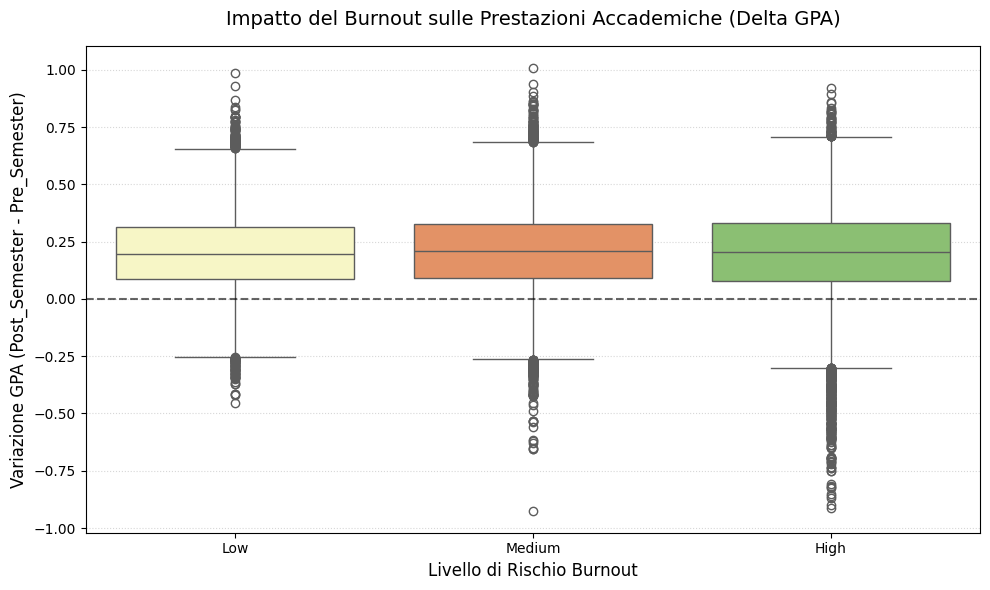

--- Media della variazione del GPA per ogni livello di Burnout ---
Burnout_Risk_Level
High      0.195644
Low       0.200381
Medium    0.209838
Name: GPA_Delta, dtype: float64


In [22]:
# 1. Creiamo la nuova colonna con la differenza del GPA (Voto Post - Voto Pre)
# Un valore NEGATIVO significa che i voti sono peggiorati a fine semestre
# Un valore POSITIVO significa che lo studente è migliorato
X_train['GPA_Delta'] = X_train['Post_Semester_GPA'] - X_train['Pre_Semester_GPA']

# 2. Configuriamo la dimensione del grafico
plt.figure(figsize=(10, 6))

# 3. Creiamo il Box Plot
sns.boxplot(
    data=X_train,
    x="Burnout_Risk_Level",
    y="GPA_Delta",
    order=['Low', 'Medium', 'High'], # Ordine logico del burnout
    palette="RdYlGn_r",               # Scala di colori: dal verde (low) al rosso (high)
    hue="Burnout_Risk_Level",
    legend=False
)

# 4. Aggiungiamo una linea orizzontale sullo ZERO per vedere chi migliora e chi peggiora
plt.axhline(y=0, color='black', linestyle='--', alpha=0.6, label="Nessun Cambiamento")

# 5. Personalizziamo i dettagli del grafico
plt.title("Impatto del Burnout sulle Prestazioni Accademiche (Delta GPA)", fontsize=14, pad=15)
plt.xlabel("Livello di Rischio Burnout", fontsize=12)
plt.ylabel("Variazione GPA (Post_Semester - Pre_Semester)", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Eseguiamo anche un controllo numerico stampando le medie esatte per ogni gruppo
print("--- Media della variazione del GPA per ogni livello di Burnout ---")
print(X_train.groupby('Burnout_Risk_Level')['GPA_Delta'].mean())

La prima cosa che salta all'occhio è che le tre "scatole" (i rettangoli che contengono il 50% centrale degli studenti) si trovano esattamente alla stessa altezza, indipendentemente dal livello di Burnout (Low, Medium, High).

OSSERVAZIONE SUL HIGH : Sebbene la maggior parte degli studenti resista allo stress mantenendo voti alti, esiste un sotto-gruppo specifico di studenti ad alto burnout che subisce un crollo drammatico e verticale delle prestazioni accademiche.

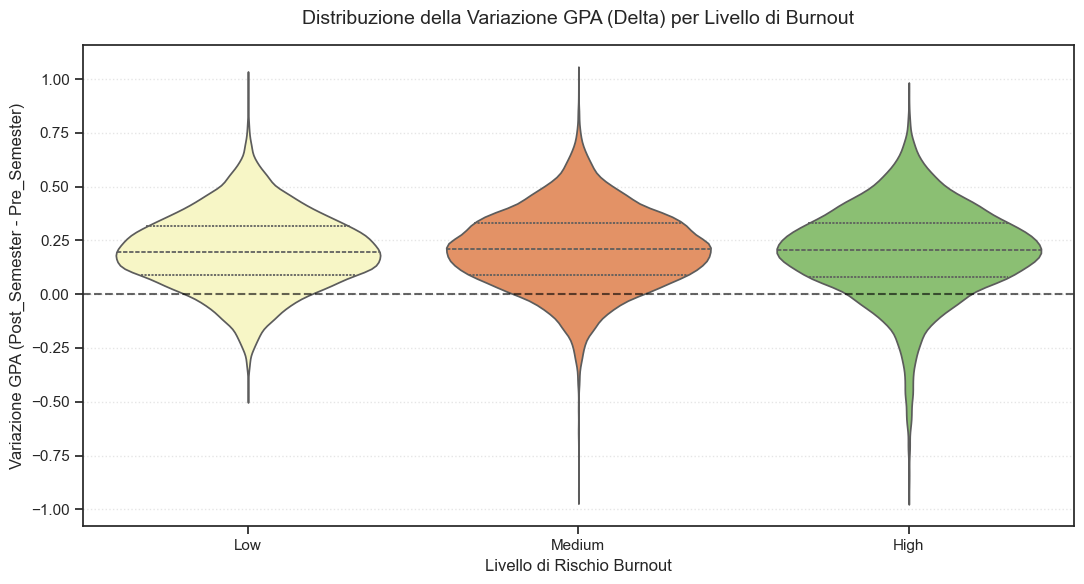

--- Media della variazione del GPA per ogni livello di Burnout ---
Burnout_Risk_Level
High      0.195644
Low       0.200381
Medium    0.209838
Name: GPA_Delta, dtype: float64


In [31]:
# 1. Creiamo la colonna con la differenza del GPA (se non è già stata creata)
X_train['GPA_Delta'] = X_train['Post_Semester_GPA'] - X_train['Pre_Semester_GPA']

# 2. Configuriamo la dimensione del grafico
plt.figure(figsize=(11, 6))

# 3. Creiamo il Violin Plot
sns.violinplot(
    data=X_train,
    x="Burnout_Risk_Level",
    y="GPA_Delta",
    order=['Low', 'Medium', 'High'], # Ordine logico del burnout
    palette="RdYlGn_r",               # Dal verde (low) al rosso (high)
    hue="Burnout_Risk_Level",
    legend=False,
    inner="quartiles"                 # Mostra la mediana e i quartili come linee tratteggiate dentro i violini
)

# 4. Aggiungiamo la linea orizzontale sullo ZERO (riferimento di nessun cambiamento)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.6, label="Nessun Cambiamento")

# 5. Personalizziamo i dettagli del grafico
plt.title("Distribuzione della Variazione GPA (Delta) per Livello di Burnout", fontsize=14, pad=15)
plt.xlabel("Livello di Rischio Burnout", fontsize=12)
plt.ylabel("Variazione GPA (Post_Semester - Pre_Semester)", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Controllo numerico delle medie (sempre utile da affiancare al grafico)
print("--- Media della variazione del GPA per ogni livello di Burnout ---")
print(X_train.groupby('Burnout_Risk_Level')['GPA_Delta'].mean())

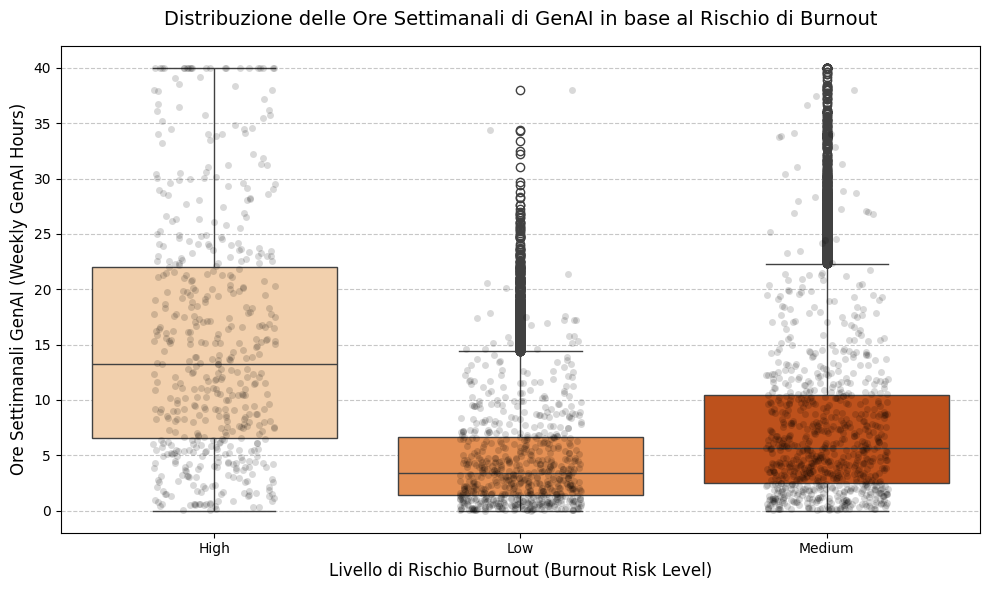

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuriamo la dimensione del grafico
plt.figure(figsize=(10, 6))

# 2. Creiamo il Box Plot
# Impostiamo x sull'asse del Burnout e y sulle ore di utilizzo della GenAI
sns.boxplot(
    data=X_train,
    x="Burnout_Risk_Level",
    y="Weekly_GenAI_Hours",
    palette="Oranges",  # Una scala di colori sfumata sull'arancione/rosso per il burnout
    hue="Burnout_Risk_Level",  # Evita il warning di Seaborn assegnando i colori alle categorie
    legend=False,
)

# 3. Aggiungiamo un tocco di eleganza con uno "Swarm" o "Strip" plot sovrapposto (Opzionale)
# Questo serve a vedere i singoli punti (studenti) se il dataset non è troppo pesante,
# ma avendo 50.000 righe usiamo 'jitter' leggero solo per dare l'idea della densità senza bloccare il pc.
sns.stripplot(
    data=X_train.sample(
        2000
    ),  # Prendiamo un campione di 2000 studenti per non appesantire il grafico
    x="Burnout_Risk_Level",
    y="Weekly_GenAI_Hours",
    color="black",
    alpha=0.15,  # Punti molto trasparenti per vedere dove si concentrano
    jitter=0.2,
)

# 4. Personalizziamo i titoli e le etichette
plt.title(
    "Distribuzione delle Ore Settimanali di GenAI in base al Rischio di Burnout",
    fontsize=14,
    pad=15,
)
plt.xlabel("Livello di Rischio Burnout (Burnout Risk Level)", fontsize=12)
plt.ylabel("Ore Settimanali GenAI (Weekly GenAI Hours)", fontsize=12)

# 5. Mostriamo il grafico
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Linee di griglia solo orizzontali
plt.tight_layout()
plt.show()

C'è una relazione diretta e fortissima. Gli studenti che soffrono di un alto rischio di burnout passano mediamente il triplo del tempo sulla GenAI rispetto a chi ha un rischio basso.

Esistono delle eccezioni interessanti. Ci sono studenti che usano l'IA moltissimo (fino a 25-30 ore a settimana) ma dichiarano comunque un rischio di burnout Basso o Medio.

gli outlier del low e medium sono probablimente studenti che usano tanto ma non ricadono nel burnout perchè sono altamente competenti nell'uso della ai. VERIFICO L'IPOTESI


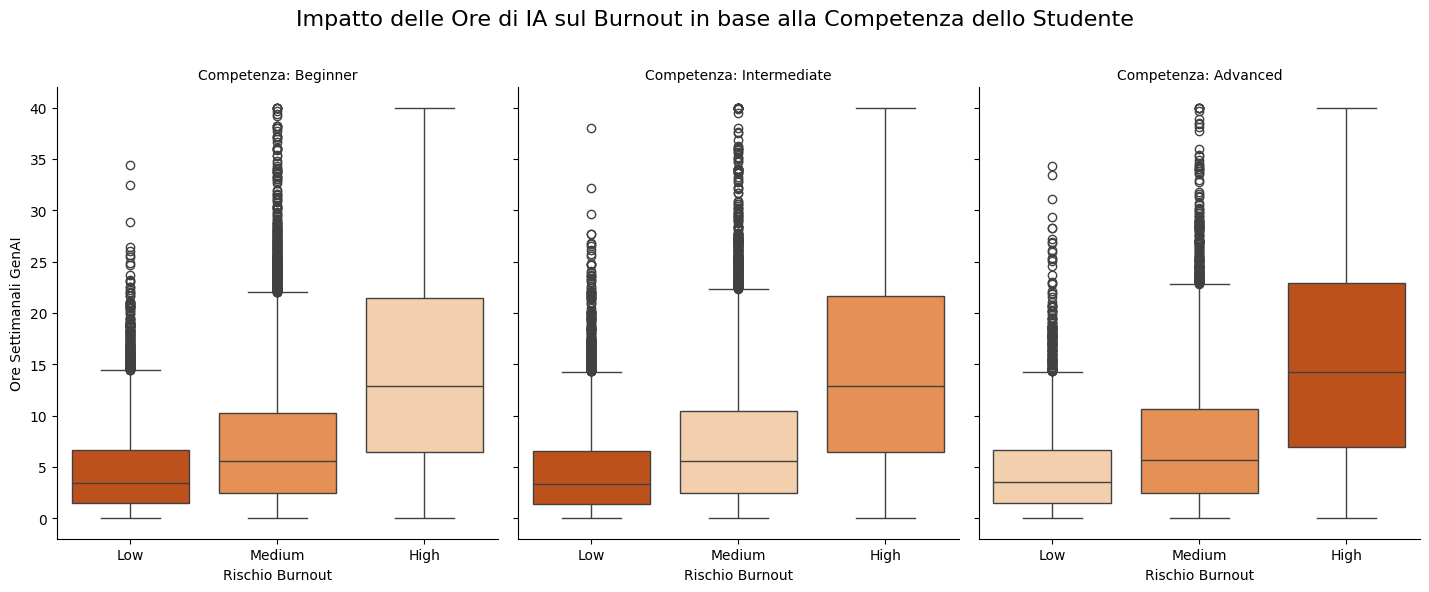

In [16]:
# Configura una griglia di grafici: una riga, tante colonne quante sono le competenze
# Assicurati di usare la colonna testuale originale 'Prompt_Engineering_Skill' 
# così sull'interfaccia leggerai 'Beginner', 'Intermediate', 'Advanced'
g = sns.FacetGrid(
    X_train, 
    col="Prompt_Engineering_Skill", 
    col_order=['Beginner', 'Intermediate', 'Advanced'], # Ordiniamo da meno esperto a più esperto
    height=6, 
    aspect=0.8
)

# Mappiamo il Box Plot dentro la griglia
g.map_dataframe(
    sns.boxplot, 
    x="Burnout_Risk_Level", 
    y="Weekly_GenAI_Hours", 
    order=['Low', 'Medium', 'High'], # Ordine logico del rischio burnout
    palette="Oranges",
    hue="Burnout_Risk_Level",
    legend=False
)

# Aggiungiamo i titoli e i dettagli per renderlo leggibile
g.set_axis_labels("Rischio Burnout", "Ore Settimanali GenAI")
g.set_titles("Competenza: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Impatto delle Ore di IA sul Burnout in base alla Competenza dello Studente", fontsize=16)

plt.show()

i grafici si muovono all'uniso mostrandoci che:
un utente avanzato, se usa l'IA per 30 o 40 ore a settimana, rischia il burnout tanto quanto un principiante, oppure (nel caso degli outlier) riesce a non averlo per altri motivi.

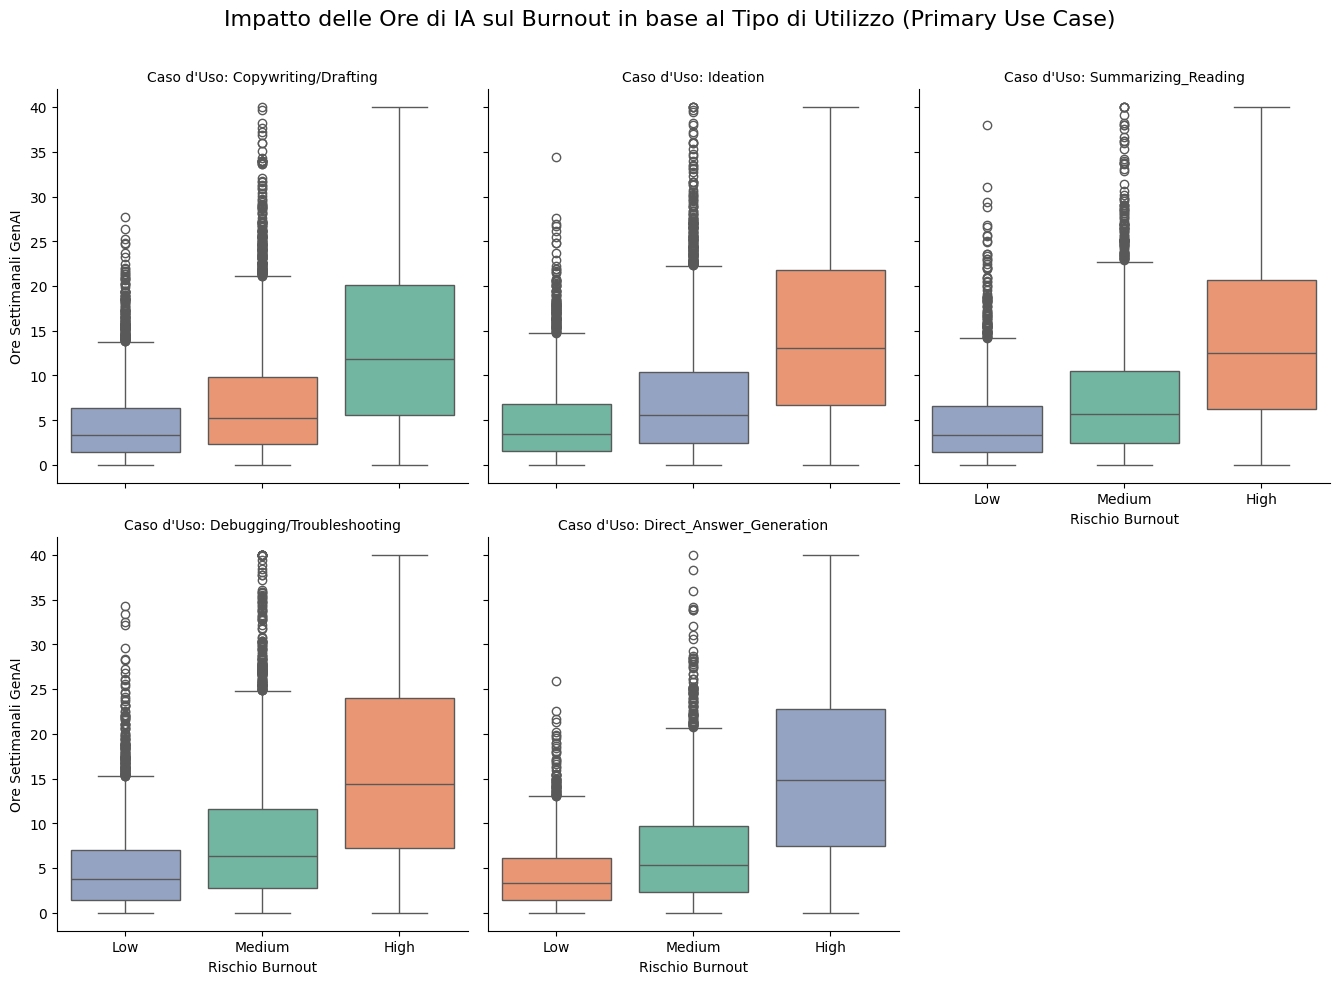

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configura la griglia in base ai diversi casi d'uso (Primary_Use_Case)
# Lasciamo che Seaborn crei automaticamente una colonna per ogni categoria unica
g = sns.FacetGrid(
    X_train, 
    col="Primary_Use_Case", 
    height=5, 
    aspect=0.9,
    col_wrap=3 # Se ci sono molte categorie, le manda a capo dopo 3 grafici per non stringerli troppo
)

# 2. Mappiamo il Box Plot dentro la griglia
g.map_dataframe(
    sns.boxplot, 
    x="Burnout_Risk_Level", 
    y="Weekly_GenAI_Hours", 
    order=['Low', 'Medium', 'High'], # Ordine logico dello stress
    palette="Set2",                  # Cambiamo palette per distinguerlo dal precedente
    hue="Burnout_Risk_Level",
    legend=False
)

# 3. Pulizia e titoli
g.set_axis_labels("Rischio Burnout", "Ore Settimanali GenAI")
g.set_titles("Caso d'Uso: {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Impatto delle Ore di IA sul Burnout in base al Tipo di Utilizzo (Primary Use Case)", fontsize=16)

plt.show()

gli andamenti non cambiano restano molto simili tra loro. 
ipotizzo che che siano altre le ragioni di quelli outlier. 

e se il burnout fosse legato alle ore di studio classico?


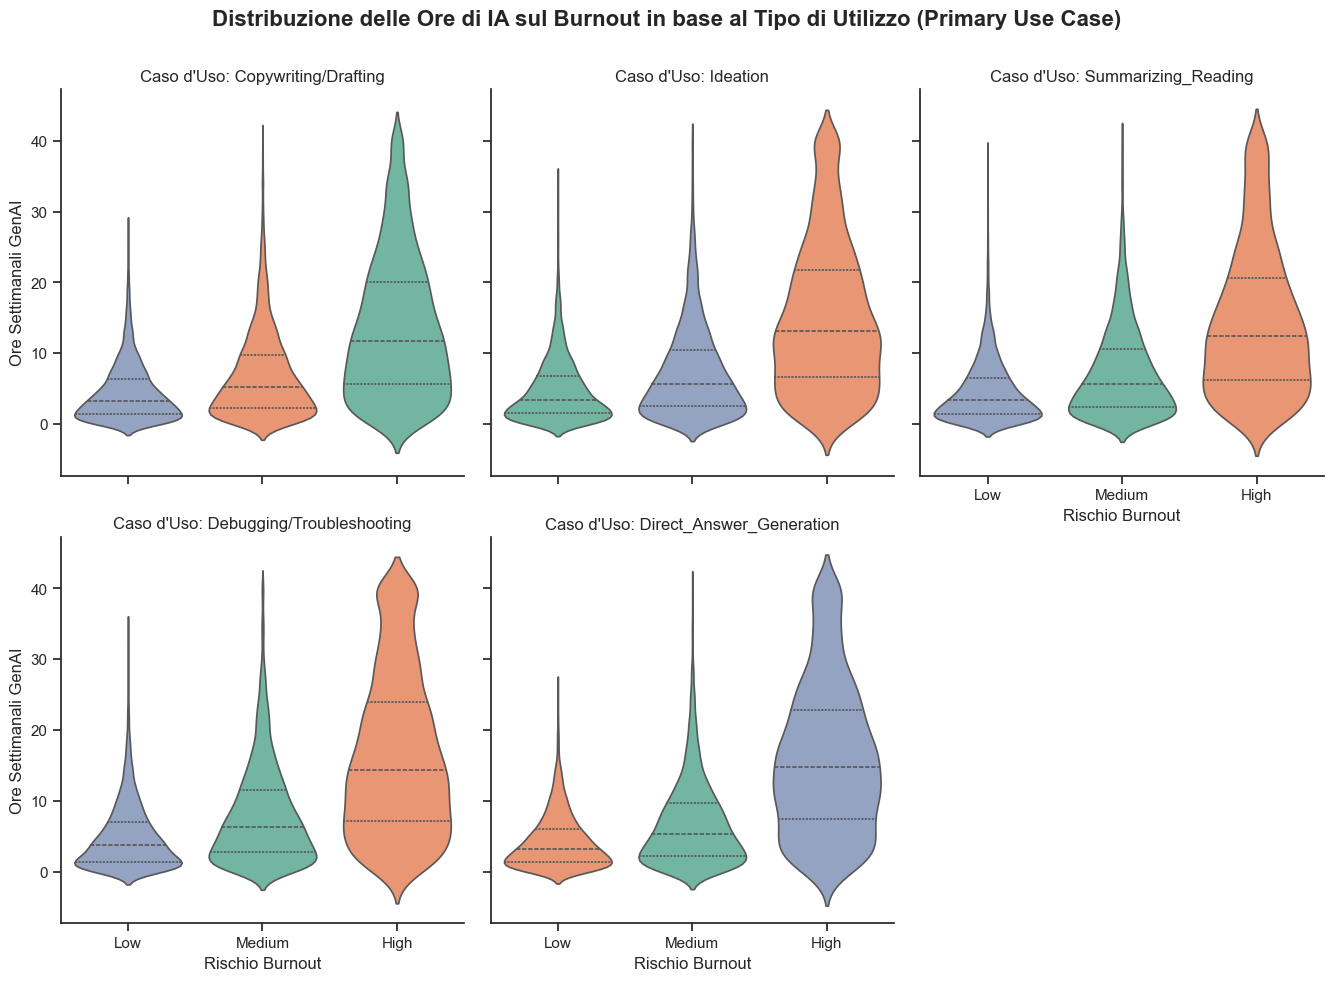

In [32]:
# 1. Configura la griglia in base ai diversi casi d'uso (Primary_Use_Case)
g = sns.FacetGrid(
    X_train, 
    col="Primary_Use_Case", 
    height=5, 
    aspect=0.9,
    col_wrap=3  # Manda a capo i grafici dopo il terzo per mantenere una buona leggibilità
)

# 2. Mappiamo il VIOLIN PLOT dentro la griglia
g.map_dataframe(
    sns.violinplot, 
    x="Burnout_Risk_Level", 
    y="Weekly_GenAI_Hours", 
    order=['Low', 'Medium', 'High'],  # Ordine logico dello stress
    hue="Burnout_Risk_Level",         # Colora i violini in base al livello di burnout
    palette="Set2",                   # Palette di colori pulita e distinta
    inner="quartiles",                # Mostra le linee tratteggiate di mediana e quartili dentro i violini
    legend=False
)

# 3. Pulizia e titoli
g.set_axis_labels("Rischio Burnout", "Ore Settimanali GenAI")
g.set_titles("Caso d'Uso: {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribuzione delle Ore di IA sul Burnout in base al Tipo di Utilizzo (Primary Use Case)", fontsize=16, weight='bold')

plt.show()

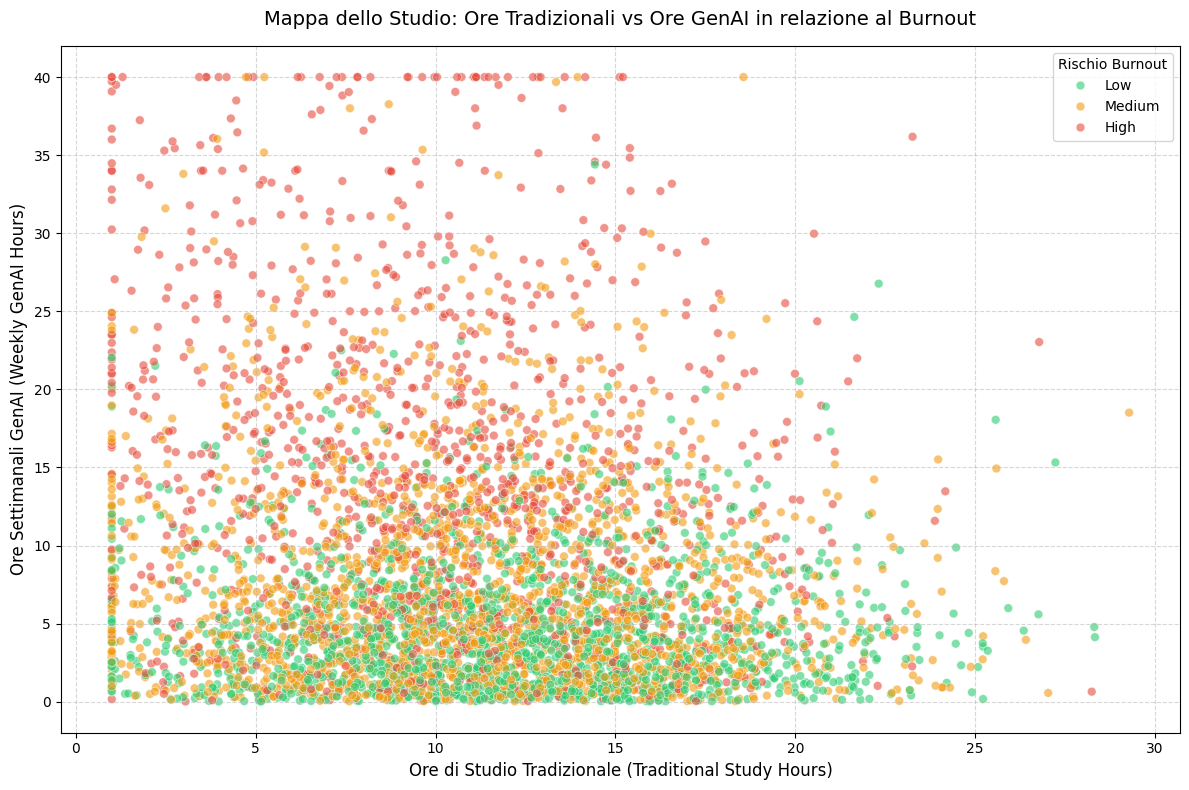

In [19]:
# 1. Configgiamo la dimensione del grafico
plt.figure(figsize=(12, 8))

# 2. Creiamo lo Scatter Plot per vedere l'interazione tra i due tipi di studio
# Usiamo un campione (sample) di 5000 studenti per evitare che i 50.000 punti si sovrappongano troppo obscuring i pattern
sns.scatterplot(
    data=X_train.sample(5000, random_state=42),
    x="Traditional_Study_Hours",
    y="Weekly_GenAI_Hours",
    hue="Burnout_Risk_Level",
    hue_order=['Low', 'Medium', 'High'],
    palette={"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}, # Verde, Arancione, Rosso
    alpha=0.6,
    s=40
)

# 3. Aggiungiamo i dettagli grafici
plt.title("Mappa dello Studio: Ore Tradizionali vs Ore GenAI in relazione al Burnout", fontsize=14, pad=15)
plt.xlabel("Ore di Studio Tradizionale (Traditional Study Hours)", fontsize=12)
plt.ylabel("Ore Settimanali GenAI (Weekly GenAI Hours)", fontsize=12)
plt.legend(title="Rischio Burnout", loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Mappa dello Studio: Ore Tradizionali vs Ore GenAI in relazione al Burnout. Questa analisi ha portato a concludere che chi passa poche ore settimanali a usare l'ai indipendentemente dal numero di ore di studio tradizionale manifesta bassi livelli di burnout, chi riscontra livelli medi di burnout non ha un andamento definito di re di studio tradizionali e uso della ai 

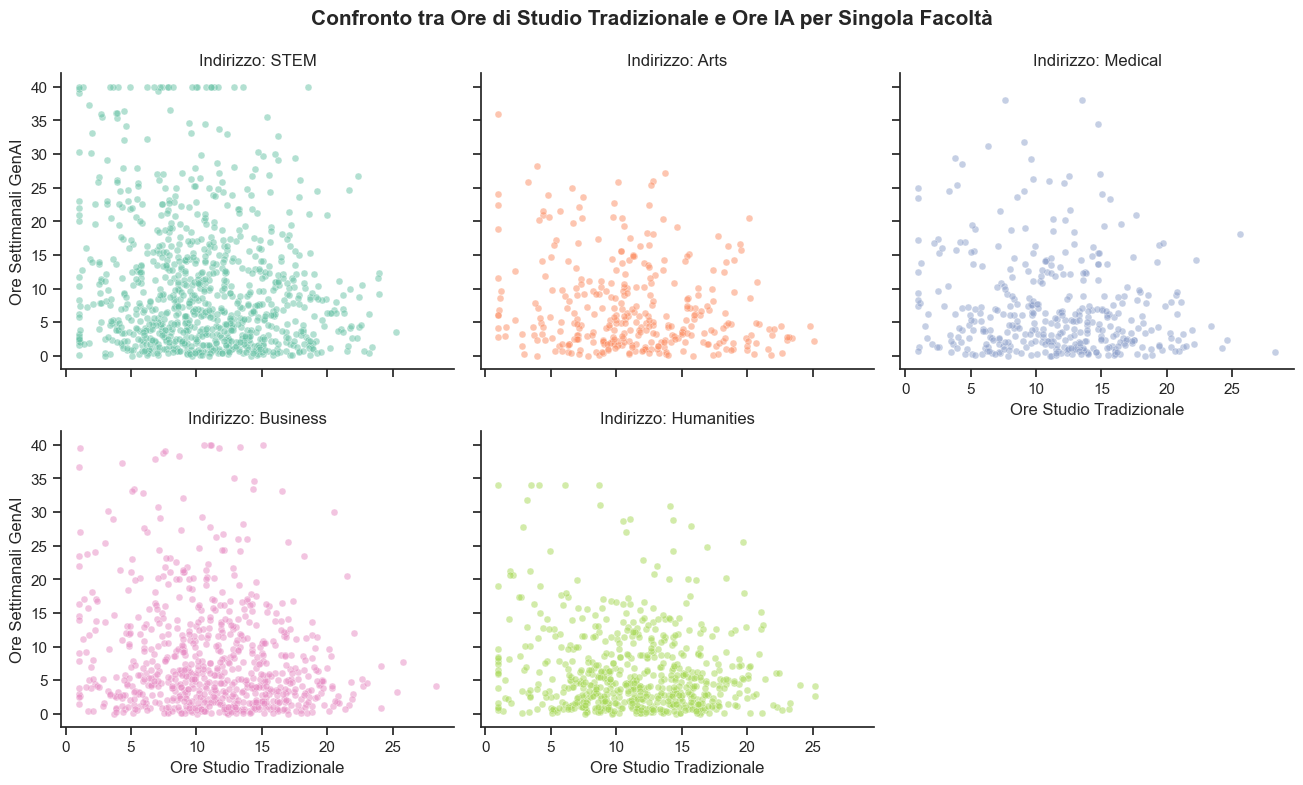

In [24]:
# Usiamo un sample controllato per non affollare i grafici
df_sample = X_train.sample(3000, random_state=42)

# Creiamo una griglia di grafici: uno per ogni facoltà (Major_Category)
# col_wrap=3 manda a capo i grafici dopo il terzo, creando una matrice pulita
g = sns.FacetGrid(
    df_sample, 
    col="Major_Category", 
    hue="Major_Category", 
    palette="Set2", 
    col_wrap=3, 
    height=4, 
    aspect=1.1
)

# Mappiamo lo scatter plot dentro ogni quadrante
g.map_dataframe(
    sns.scatterplot, 
    x="Traditional_Study_Hours", 
    y="Weekly_GenAI_Hours", 
    alpha=0.5, 
    s=25
)

# Aggiungiamo i titoli e i dettagli
g.set_axis_labels("Ore Studio Tradizionale", "Ore Settimanali GenAI")
g.set_titles("Indirizzo: {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Confronto tra Ore di Studio Tradizionale e Ore IA per Singola Facoltà", fontsize=15, weight='bold')

plt.show()

c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-pack

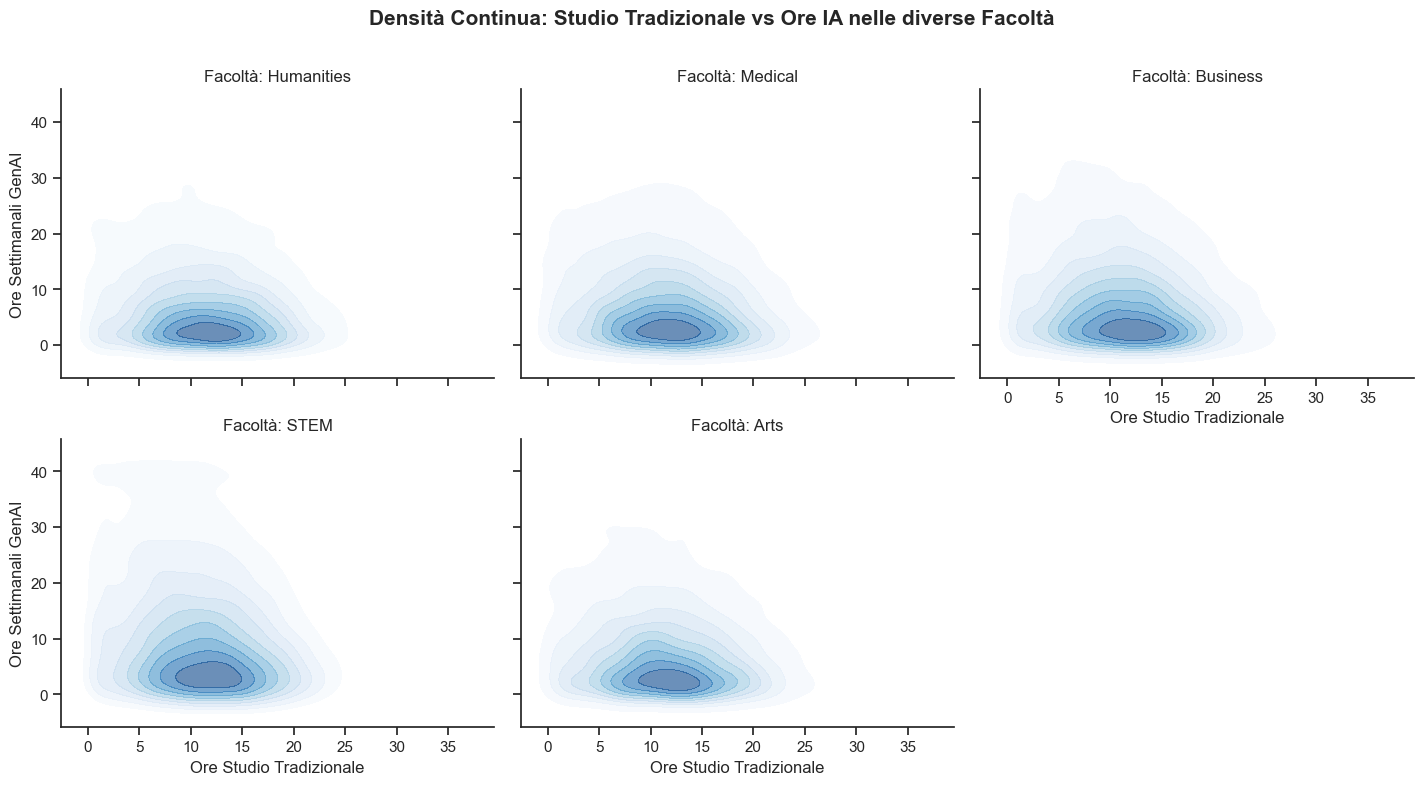

In [25]:
# Creiamo una griglia di grafici continua: uno per ogni Major_Category
g = sns.FacetGrid(
    X_train, 
    col="Major_Category", 
    hue="Major_Category", 
    palette="Dark2", 
    col_wrap=3, 
    height=4, 
    aspect=1.2
)

# Mappiamo il grafico a densità di contorno continuo (KDE bidimensionale)
g.map_dataframe(
    sns.kdeplot, 
    x="Traditional_Study_Hours", 
    y="Weekly_GenAI_Hours", 
    shade=True,          # Colora l'interno delle curve per evidenziare la densità
    thresh=0.05,         # Elimina il rumore di fondo isolato
    alpha=0.6,           # Rende le sfumature piacevoli e non troppo pesanti
    cmap="Blues"         # Scala di sfumature bluastra per la densità continua
)

# Personalizzazione dei dettagli grafici
g.set_axis_labels("Ore Studio Tradizionale", "Ore Settimanali GenAI")
g.set_titles("Facoltà: {col_name}")
plt.subplots_adjust(top=0.88)
g.fig.suptitle("Densità Continua: Studio Tradizionale vs Ore IA nelle diverse Facoltà", fontsize=15, weight='bold')

plt.show()

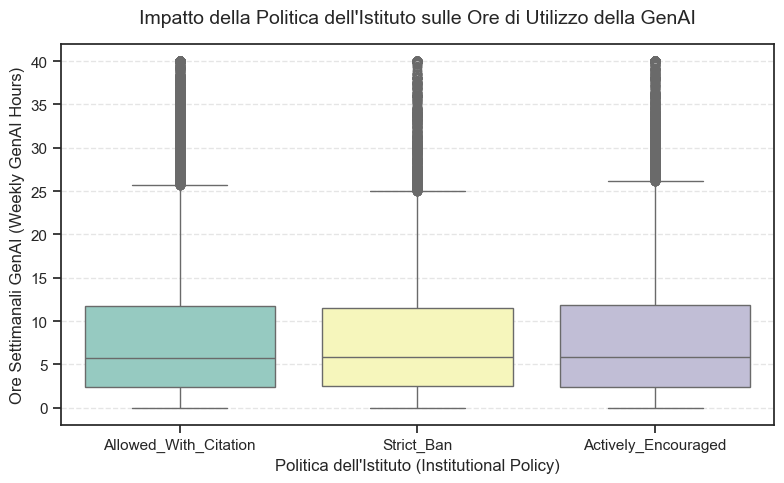

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuriama la dimensione del grafico
plt.figure(figsize=(8, 5))

# 2. Creiamo il Box Plot
sns.boxplot(
    data=X_train,
    x="Institutional_Policy",        # Politica dell'istituto sulle X
    y="Weekly_GenAI_Hours",          # Ore settimanali IA sulle Y
    palette="Set3",                  # Palette di colori chiara e ben definita
    hue="Institutional_Policy",      # Assegnazione dei colori alle categorie
    legend=False
)

# 3. Aggiungiamo i dettagli grafici per la leggibilità
plt.title("Impatto della Politica dell'Istituto sulle Ore di Utilizzo della GenAI", fontsize=14, pad=15)
plt.xlabel("Politica dell'Istituto (Institutional Policy)", fontsize=12)
plt.ylabel("Ore Settimanali GenAI (Weekly GenAI Hours)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Linee di griglia orizzontali per seguire i valori delle ore

# 4. Ottimizziamo lo spazio e mostriamo il grafico
plt.tight_layout()
plt.show()

la struttura generale dei dati (mediana, quartili) è quasi identica tra le diverse politiche.

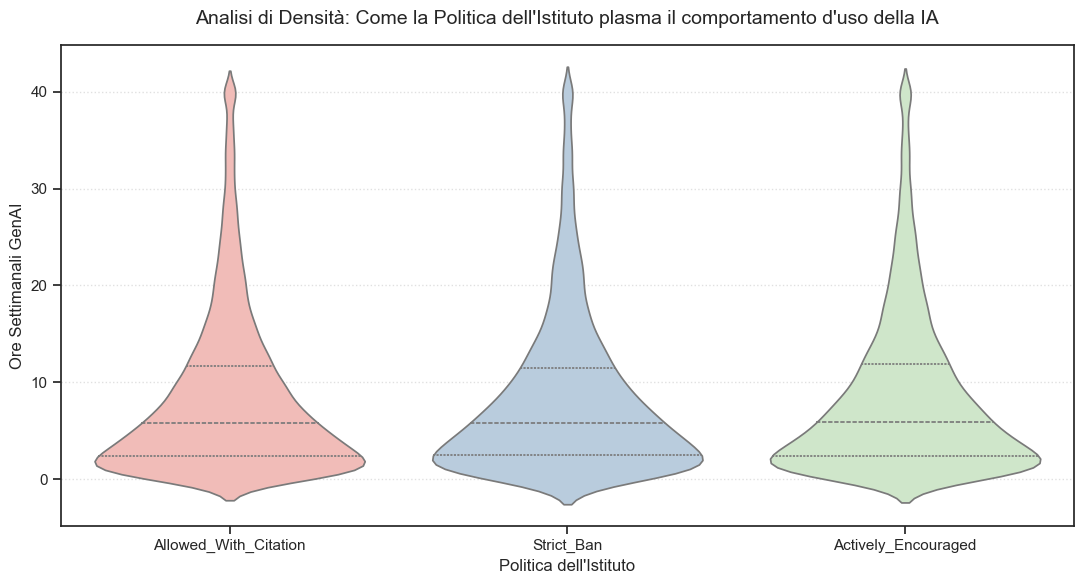

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuriamo la dimensione del grafico
plt.figure(figsize=(11, 6))

# 2. Creiamo il Violin Plot
sns.violinplot(
    data=X_train,
    x="Institutional_Policy",
    y="Weekly_GenAI_Hours",
    palette="Pastel1",
    hue="Institutional_Policy",
    legend=False,
    inner="quartiles",  # Mostra i quartili all'interno del violino come linee tratteggiate
)

# 3. Dettagli di lettura
plt.title(
    "Analisi di Densità: Come la Politica dell'Istituto plasma il comportamento d'uso della IA",
    fontsize=14,
    pad=15,
)
plt.xlabel("Politica dell'Istituto", fontsize=12)
plt.ylabel("Ore Settimanali GenAI", fontsize=12)
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()